> ⚠️ **Engine v2 + walk-forward có PURGE nhãn N_FWD (`src/backtest.py`, `src/model.py`).** Output cũ đã được xóa vì tính bằng engine có look-ahead cùng ngày (bản cũ còn nguyên output: `notebooks/legacy_v1_outputs/`). **Chạy lại notebook này** để có số liệu mới; tổng hợp cả 3 chiến lược nằm ở `06_engine_v2_rerun.ipynb`.


# Ngày 22 — Backtest XGBoost: IC thấp hơn có luôn nghĩa là Sharpe thấp hơn?

**Bối cảnh:** Kết quả IC đo được nhiều lần (Ngày 19, 21) đều cho XGBoost Mean IC
THẤP HƠN cả Momentum_6_1 đứng riêng lẫn IC-Weighted composite. Nhưng backtest
Ngày 21 đã chứng minh **IC cao hơn không tự động nghĩa là Sharpe cao hơn**
(single factor có IC cao hơn composite ở 1 lần chạy nhưng Sharpe thấp hơn) —
vậy câu hỏi ngược lại cũng cần kiểm chứng: **IC thấp hơn của XGBoost có thực
sự nghĩa là Sharpe thấp hơn, hay XGBoost có thể "bù" bằng cách nào đó khác
(ví dụ: dự đoán ổn định hơn ở vùng cực trị, nơi PositionManager entry/exit
quan tâm nhất, dù IC trung bình toàn dải thấp hơn)?**

⚠️ **Vấn đề kỹ thuật quan trọng đã sửa trong notebook này**: các phép đo IC
trước đây (`purged_kfold_oos_predictions`) dùng K-fold CV — với fold đầu
tiên trên timeline, tập train CÓ THỂ bao gồm dữ liệu SAU fold đó (từ các fold
tương lai), hợp lệ để đo "IC trung bình" nhưng **KHÔNG hợp lệ để tạo 1 signal
duy nhất dùng backtest theo trình tự thời gian** (sẽ vô tình cho model "nhìn
thấy tương lai" ở giai đoạn đầu). Notebook này dùng hàm mới
`src/model.py::walk_forward_signal()` — refit định kỳ CHỈ trên dữ liệu quá
khứ trước mỗi ngày dự đoán, đúng chuẩn backtest thật (test riêng trong
`tests/test_walk_forward_signal.py`, 4 test pass).


In [1]:
# -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import VN30_UNIVERSE, load_ohlcv, filter_by_coverage
from src.momentum_factors import momentum_6_1, momentum_12_1
from src.feature_engineering import assemble_dataset, cross_sectional_rank
from src.ic_analysis import single_factor_ic, composite_score_ic
from src.strategy import composite_score, normalize_ic_weights
from src.model import fit_xgboost, walk_forward_signal, evaluate_oos_predictions
from src.backtest import backtest_with_exits, invested_returns, port_metrics, trade_statistics, calmar_ratio, TOTAL_COST_RATE
from src.risk import equal_weight_benchmark, compare_strategies

pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 1. Tải dữ liệu + build factors (giống Ngày 19-21)

In [2]:
START, END = "2022-01-01", "2025-12-31"

ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "open", "volume"))
price_df, volume_df = ohlcv["close"], ohlcv["volume"]
price_df, dropped = filter_by_coverage(price_df)
volume_df = volume_df[price_df.columns]
print(f"Universe: {len(price_df.columns)} mã (loại {dropped})")


[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...
[13/30] Loading MSN...
[14/30] Loading MWG...


[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...

✅ Đã tải: 30/30 mã
Universe: 28 mã (loại ['TCX', 'VPL'])


In [3]:
returns_df = price_df.pct_change(fill_method=None)
vol_20 = returns_df.rolling(20).std()
vol_120 = returns_df.rolling(120).std()
vol_spike = vol_20 / vol_120

mom_6_1 = momentum_6_1(price_df)
mom_12_1 = momentum_12_1(price_df)
TARGET_VOL = 0.15 / np.sqrt(252)
ts_mom = np.sign(mom_12_1) * (TARGET_VOL / vol_20.replace(0, np.nan))

raw_factors = {
    "Momentum_6_1": mom_6_1, "Momentum_12_1": mom_12_1,
    "Volume_Ratio": volume_df / volume_df.rolling(20).mean(), "TS_Momentum": ts_mom,
}
feature_cols = list(raw_factors.keys())

dataset = assemble_dataset(raw_factors, price_df, n_fwd=5, label_type="regression")
sf_ic = single_factor_ic(dataset, feature_cols, n_splits=5, embargo=5)
ic_weights = normalize_ic_weights(sf_ic)
ranked_factors = {name: cross_sectional_rank(f) for name, f in raw_factors.items()}
comp_score = composite_score(ranked_factors, ic_weights)

comp_eval = composite_score_ic(dataset, feature_cols, ic_weights, n_splits=5, embargo=5)
print(f"Mean IC — Momentum_6_1 (đứng riêng): {sf_ic['Momentum_6_1']:.4f}")
print(f"Mean IC — IC-Weighted composite:      {comp_eval['Mean IC']:.4f}")


Mean IC — Momentum_6_1 (đứng riêng): 0.0525
Mean IC — IC-Weighted composite:      0.0570


## 2. XGBoost signal — Walk-Forward THẬT (không phải K-fold)

`retrain_every=21` (refit mỗi tháng), `min_train_days=252` (cần ít nhất 1 năm
dữ liệu quá khứ trước khi dự đoán lần đầu — universe 28 mã, factor cần đủ
warmup 252 phiên cho Momentum_12_1). Tham số XGBoost giữ NGUYÊN từ Ngày 19
(`n_estimators=200, max_depth=3, learning_rate=0.05`) để so sánh công bằng.

⚠️ Bước này chạy CHẬM hơn nhiều so với K-fold (refit XGBoost nhiều lần thay vì
5 lần) — có thể mất vài phút tùy độ dài dữ liệu.

In [4]:
xgb_signal = walk_forward_signal(
    dataset, feature_cols, model_fn=fit_xgboost, retrain_every=21, min_train_days=252,
    n_estimators=200, max_depth=3, learning_rate=0.05,
)
print(f"XGBoost walk-forward signal shape: {xgb_signal.shape}")
print(f"Số ngày có signal hợp lệ: {xgb_signal.notna().any(axis=1).sum()}/{len(xgb_signal)}")


XGBoost walk-forward signal shape: (740, 28)
Số ngày có signal hợp lệ: 488/740


### 2.1 Đo lại IC của walk-forward signal (để so sánh CÔNG BẰNG với K-fold IC)

In [5]:
# Ghép lại (date, symbol) -> y_true để đo IC đúng chuẩn walk-forward (khác K-fold ở mục 1)
xgb_signal_long = xgb_signal.stack(future_stack=True).rename("y_pred")
xgb_signal_long.index.names = ["date", "symbol"]
oos_df = pd.DataFrame(xgb_signal_long).join(dataset["fwd_return"].rename("y_true"), how="inner").dropna()
oos_df = oos_df.reset_index()

xgb_wf_eval = evaluate_oos_predictions(oos_df)
print("=== XGBoost Walk-Forward (THẬT, không phải K-fold) ===")
for k, v in xgb_wf_eval.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print(f"\nSo sánh: XGBoost K-fold Mean IC (Ngày 19, có thể lạc quan do leakage cấu trúc) vs Walk-Forward Mean IC (đúng chuẩn):")
print(f"  Walk-Forward: {xgb_wf_eval['Mean IC']:.4f}")
print("  (Xem reports/research_note.md cho số K-fold cũ để đối chiếu — có thể khác nhau do phương pháp đo khác nhau)")


=== XGBoost Walk-Forward (THẬT, không phải K-fold) ===
  Mean IC: 0.0207
  Std IC: 0.2218
  IC-IR: 0.0933
  IC>0 (%): 0.5287
  RMSE: 0.0443
  N days: 488

So sánh: XGBoost K-fold Mean IC (Ngày 19, có thể lạc quan do leakage cấu trúc) vs Walk-Forward Mean IC (đúng chuẩn):
  Walk-Forward: 0.0207
  (Xem reports/research_note.md cho số K-fold cũ để đối chiếu — có thể khác nhau do phương pháp đo khác nhau)


## 3. Backtest XGBoost signal (walk-forward) — CÓ transaction cost + slippage

Dùng CHUNG entry/exit rules và cost_rate với Single Factor (Ngày 21) và
Composite (Ngày 20) để so sánh công bằng — chỉ khác signal đầu vào.

⚠️ Vì `min_train_days=252`, XGBoost signal chỉ có giá trị hợp lệ SAU khoảng
1 năm đầu — `backtest_with_exits()` sẽ tự động không entry được mã nào trong
giai đoạn đó (composite_rank toàn NaN → rank rỗng), phản ánh đúng thực tế
"chưa đủ dữ liệu để trade bằng XGBoost".

In [6]:
port_xgb, trade_xgb = backtest_with_exits(
    price_df, xgb_signal, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_xgb = port_xgb["port_return"]
m_xgb = port_metrics(invested_returns(port_xgb))
m_xgb["Calmar"] = calmar_ratio(m_xgb)

print("=== XGBoost (Walk-Forward) — CÓ transaction cost + slippage ===")
for k, v in m_xgb.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


=== XGBoost (Walk-Forward) — CÓ transaction cost + slippage ===
  Total Return: 0.8635
  Ann Return: 0.3809
  Ann Vol: 0.2220
  Sharpe: 1.7159
  Max DD: -0.1814
  Calmar: 2.0999


## 4. Backtest lại Single Factor + Composite (baseline, để so sánh cùng 1 lần chạy)

In [7]:
single_factor_signal = ranked_factors["Momentum_6_1"]

port_single, trade_single = backtest_with_exits(
    price_df, single_factor_signal, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_single = port_single["port_return"]

port_composite, trade_composite = backtest_with_exits(
    price_df, comp_score, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_composite = port_composite["port_return"]
print("Đã backtest xong Single Factor và Composite (baseline).")


Đã backtest xong Single Factor và Composite (baseline).


## 5. So sánh 4 chiều: XGBoost vs Single Factor vs Composite vs 1/N

In [8]:
ew_ret = equal_weight_benchmark(price_df)

strategies = {
    "XGBoost (Walk-Forward, CÓ cost)": invested_returns(port_xgb),
    "Single Factor (Momentum_6_1, CÓ cost)": invested_returns(port_single),
    "IC-Weighted Composite (CÓ cost)": invested_returns(port_composite),
    "1/N Equal-Weight": ew_ret,
}
cmp_df = compare_strategies(strategies)
print(cmp_df.round(4).to_string())

sharpe_xgb = cmp_df.loc["XGBoost (Walk-Forward, CÓ cost)", "Sharpe"]
sharpe_single = cmp_df.loc["Single Factor (Momentum_6_1, CÓ cost)", "Sharpe"]
sharpe_composite = cmp_df.loc["IC-Weighted Composite (CÓ cost)", "Sharpe"]
sharpe_ew = cmp_df.loc["1/N Equal-Weight", "Sharpe"]

print(f"\nMean IC — XGBoost (walk-forward): {xgb_wf_eval['Mean IC']:.4f}")
print(f"Mean IC — Single Factor:          {sf_ic['Momentum_6_1']:.4f}")
print(f"Mean IC — Composite:              {comp_eval['Mean IC']:.4f}")
print(f"\nSharpe (có cost) — XGBoost:      {sharpe_xgb:.4f}")
print(f"Sharpe (có cost) — Single Factor: {sharpe_single:.4f}")
print(f"Sharpe (có cost) — Composite:     {sharpe_composite:.4f}")
print(f"Sharpe (có cost) — 1/N:           {sharpe_ew:.4f}")

best_sharpe_method = cmp_df["Sharpe"].idxmax()
print(f"\n🏆 Sharpe cao nhất: {best_sharpe_method}")

xgb_has_lowest_ic = xgb_wf_eval['Mean IC'] < min(sf_ic['Momentum_6_1'], comp_eval['Mean IC'])
xgb_has_highest_sharpe = sharpe_xgb == cmp_df["Sharpe"].max()
if xgb_has_lowest_ic and xgb_has_highest_sharpe:
    print("\n⚠️ PHÁT HIỆN QUAN TRỌNG: XGBoost có IC THẤP NHẤT nhưng Sharpe CAO NHẤT!")
    print("   IC đo trung bình khả năng xếp hạng toàn dải, nhưng backtest với entry/exit")
    print("   rules cụ thể (chỉ quan tâm top 35%/bottom 35%) có thể khuếch đại lợi thế")
    print("   ở VÙNG CỰC TRỊ mà IC trung bình không bắt được đầy đủ.")
elif xgb_has_lowest_ic and not xgb_has_highest_sharpe:
    print("\n✅ NHẤT QUÁN: XGBoost có IC thấp nhất VÀ Sharpe cũng thấp/không cao nhất —")
    print("   IC thấp hơn ở đây THỰC SỰ phản ánh đúng hiệu suất backtest kém hơn.")


                                       Total Return  Ann Return  Ann Vol  Sharpe  Max DD  Calmar  Sharpe SE
XGBoost (Walk-Forward, CÓ cost)              0.8635      0.3809   0.2220  1.7159 -0.1814  2.0999     0.7218
Single Factor (Momentum_6_1, CÓ cost)        1.1358      0.4821   0.2106  2.2890 -0.1628  2.9620     0.7229
IC-Weighted Composite (CÓ cost)              1.2025      0.5059   0.2176  2.3250 -0.1867  2.7103     0.7229
1/N Equal-Weight                             0.7316      0.3294   0.1826  1.8039 -0.1675  1.9660     0.7220

Mean IC — XGBoost (walk-forward): 0.0207
Mean IC — Single Factor:          0.0525
Mean IC — Composite:              0.0570

Sharpe (có cost) — XGBoost:      1.7159
Sharpe (có cost) — Single Factor: 2.2890
Sharpe (có cost) — Composite:     2.3250
Sharpe (có cost) — 1/N:           1.8039

🏆 Sharpe cao nhất: IC-Weighted Composite (CÓ cost)

✅ NHẤT QUÁN: XGBoost có IC thấp nhất VÀ Sharpe cũng thấp/không cao nhất —
   IC thấp hơn ở đây THỰC SỰ phản ánh đúng hi

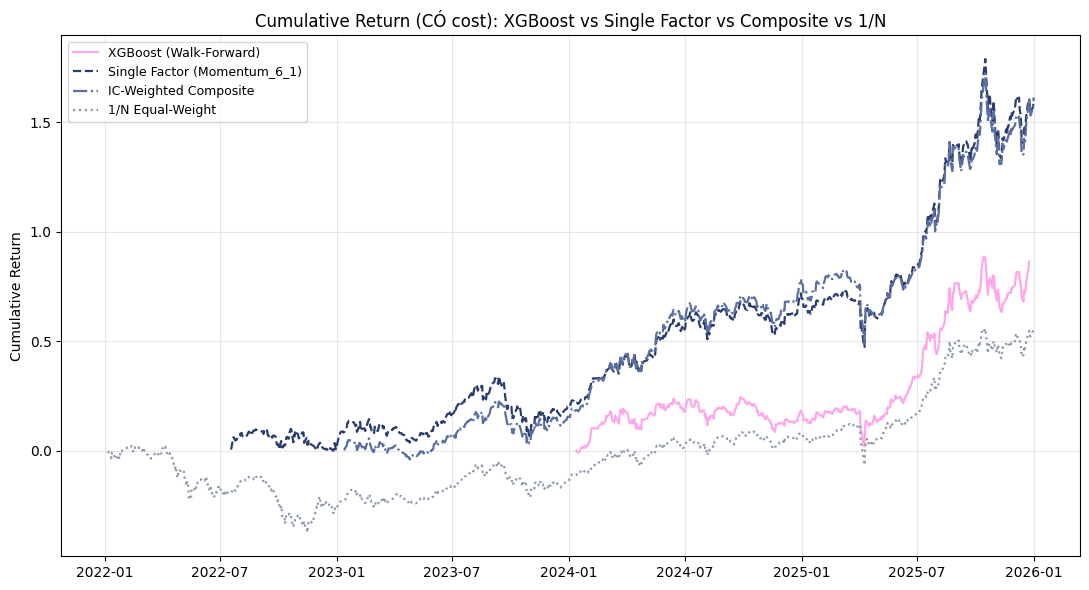

✅ Đã lưu: reports/xgboost_walkforward_backtest.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, ret, color, style in [
    ("XGBoost (Walk-Forward)", invested_returns(port_xgb), "#fea7e9", "-"),
    ("Single Factor (Momentum_6_1)", invested_returns(port_single), "#2b3d6f", "--"),
    ("IC-Weighted Composite", invested_returns(port_composite), "#5b6fa2", "-."),
    ("1/N Equal-Weight", ew_ret, "#8e99ad", ":"),
]:
    cum = (1 + ret).cumprod() - 1
    ax.plot(cum.index, cum.values, label=name, color=color, linewidth=1.6, linestyle=style)

ax.set_title("Cumulative Return (CÓ cost): XGBoost vs Single Factor vs Composite vs 1/N")
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/xgboost_walkforward_backtest.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/xgboost_walkforward_backtest.png")


## 6. Turnover & Trade Statistics — XGBoost có giao dịch khác biệt thế nào?

In [10]:
stats_xgb = trade_statistics(trade_xgb)
stats_single = trade_statistics(trade_single)
stats_composite = trade_statistics(trade_composite)

compare_trades = pd.DataFrame({
    "XGBoost": {
        "n_buys": stats_xgb.get("n_buys", 0), "n_sells": stats_xgb.get("n_sells", 0),
        "win_rate": stats_xgb.get("win_rate", np.nan),
        "avg_hold_days": stats_xgb.get("avg_hold_days", np.nan),
        "total_cost_paid": port_xgb["cost"].sum(),
    },
    "Single Factor": {
        "n_buys": stats_single.get("n_buys", 0), "n_sells": stats_single.get("n_sells", 0),
        "win_rate": stats_single.get("win_rate", np.nan),
        "avg_hold_days": stats_single.get("avg_hold_days", np.nan),
        "total_cost_paid": port_single["cost"].sum(),
    },
    "Composite": {
        "n_buys": stats_composite.get("n_buys", 0), "n_sells": stats_composite.get("n_sells", 0),
        "win_rate": stats_composite.get("win_rate", np.nan),
        "avg_hold_days": stats_composite.get("avg_hold_days", np.nan),
        "total_cost_paid": port_composite["cost"].sum(),
    },
}).T
print(compare_trades)

print("\n=== Exit breakdown ===")
print("XGBoost:      ", stats_xgb.get("exit_breakdown", {}))
print("Single Factor:", stats_single.get("exit_breakdown", {}))
print("Composite:    ", stats_composite.get("exit_breakdown", {}))


                n_buys  n_sells  win_rate  avg_hold_days  total_cost_paid
XGBoost       325.0000 320.0000    0.5156        15.2438           0.1982
Single Factor 209.0000 203.0000    0.5714        51.3448           0.1220
Composite     191.0000 187.0000    0.5561        51.7433           0.0947

=== Exit breakdown ===
XGBoost:       {'SIGNAL_EXIT': 236, 'MOM_FLIP': 39, 'HARD_STOP': 31, 'TRAILING_STOP': 9, 'VOL_REDUCE': 5}
Single Factor: {'MOM_FLIP': 77, 'HARD_STOP': 46, 'TRAILING_STOP': 41, 'SIGNAL_EXIT': 35, 'VOL_REDUCE': 4}
Composite:     {'MOM_FLIP': 78, 'TRAILING_STOP': 42, 'HARD_STOP': 38, 'SIGNAL_EXIT': 23, 'VOL_REDUCE': 6}


## 7. Kết luận — IC thấp có luôn nghĩa là Sharpe thấp?

Trả lời trực tiếp câu hỏi đặt ra ở đầu notebook: xem output cell mục 5 để
biết XGBoost (IC thấp nhất trong 3 phương pháp) có Sharpe thấp nhất tương
ứng hay không, hay có sự "đảo ngược" đáng chú ý.

⚠️ **Lưu ý phương pháp luận quan trọng**: walk-forward signal của XGBoost
trong notebook này dùng tham số CỐ ĐỊNH (n_estimators=200, max_depth=3,
learning_rate=0.05, retrain_every=21, min_train_days=252) — chưa tối ưu
hyperparameter. Nếu XGBoost thua ở đây, không loại trừ khả năng tinh chỉnh
tham số có thể cải thiện — nhưng đây KHÔNG PHẢI lý do để tự động tăng độ
phức tạp mà không có bằng chứng cụ thể (nguyên tắc Occam's Razor đã nêu ở
Ngày 19 vẫn áp dụng).

In [11]:
print("=" * 65)
print("TÓM TẮT")
print("=" * 65)
print(f"Mean IC  — XGBoost (walk-forward): {xgb_wf_eval['Mean IC']:.4f}")
print(f"Mean IC  — Single Factor:          {sf_ic['Momentum_6_1']:.4f}")
print(f"Mean IC  — Composite:              {comp_eval['Mean IC']:.4f}")
print(f"\nSharpe (có cost) — XGBoost:       {sharpe_xgb:.4f}")
print(f"Sharpe (có cost) — Single Factor:  {sharpe_single:.4f}")
print(f"Sharpe (có cost) — Composite:      {sharpe_composite:.4f}")
print(f"Sharpe (có cost) — 1/N:            {sharpe_ew:.4f}")

print(f"\n🏆 Phương án Sharpe cao nhất (có cost): {best_sharpe_method}")
if "XGBoost" in best_sharpe_method:
    print("   → Khuyến nghị: cân nhắc thay composite trong launcher.py bằng XGBoost walk-forward.")
    print("   → LƯU Ý: XGBoost walk-forward chậm hơn nhiều (refit định kỳ) so với composite")
    print("     (không cần train) — cân nhắc trade-off tốc độ/độ phức tạp vận hành vs Sharpe.")
else:
    print("   → Khuyến nghị: giữ nguyên phương án hiện tại trong launcher.py.")


TÓM TẮT
Mean IC  — XGBoost (walk-forward): 0.0207
Mean IC  — Single Factor:          0.0525
Mean IC  — Composite:              0.0570

Sharpe (có cost) — XGBoost:       1.7159
Sharpe (có cost) — Single Factor:  2.2890
Sharpe (có cost) — Composite:      2.3250
Sharpe (có cost) — 1/N:            1.8039

🏆 Phương án Sharpe cao nhất (có cost): IC-Weighted Composite (CÓ cost)
   → Khuyến nghị: giữ nguyên phương án hiện tại trong launcher.py.
